# Distributed Evolutionary Algorithms in Python (DEAP)

This notebook demonstrates a simple and explainable implementation of a distributed evolutionary algorithm using the DEAP library. The example will cover all key aspects: problem definition, algorithm setup, execution, and result analysis.

## 1. Install and Import Required Libraries
We use DEAP for evolutionary algorithms and matplotlib for visualization.

In [1]:
# Install DEAP if not already installed
!uv pip install deap matplotlib --quiet

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt
from deap import base, creator, tools, algorithms

## 2. Define the Optimization Problem
We will solve a simple optimization problem: maximize the function f(x) = x * sin(10πx) + 1.0 in the range [0, 1].

In [3]:
def eval_func(individual):
    x = individual[0]
    return (x * np.sin(10 * np.pi * x) + 1.0,)

## 3. Set Up the DEAP Toolbox
We define the individual, population, and genetic operators (selection, crossover, mutation).

In [4]:
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()
toolbox.register("attr_float", random.uniform, 0, 1)
toolbox.register(
    "individual", tools.initRepeat, creator.Individual, toolbox.attr_float, 1
)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("evaluate", eval_func)
toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=0.1, indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)

## 4. Run the Evolutionary Algorithm
We run the algorithm and collect statistics for analysis.

In [5]:
pop = toolbox.population(n=50)
hof = tools.HallOfFame(1)
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("avg", np.mean)
stats.register("max", np.max)

pop, log = algorithms.eaSimple(
    pop,
    toolbox,
    cxpb=0.7,
    mutpb=0.2,
    ngen=30,
    stats=stats,
    halloffame=hof,
    verbose=True,
)

gen	nevals	avg     	max    
0  	50    	0.833315	1.84732
1  	27    	1.07614 	1.84732
2  	45    	1.28619 	1.84732
3  	39    	1.27559 	1.84905
4  	38    	1.5151  	1.85036
5  	40    	1.75829 	1.85059
6  	36    	1.84701 	1.85059
7  	40    	1.80709 	1.85059
8  	35    	1.72969 	1.85059
9  	37    	1.81851 	1.85059
10 	43    	1.83722 	1.85059
11 	37    	1.8233  	1.8506 
12 	39    	1.78892 	1.8506 
13 	34    	1.84016 	1.8506 
14 	36    	1.79493 	1.8506 
15 	41    	1.84256 	1.8506 
16 	38    	1.78371 	1.8506 
17 	35    	1.80375 	1.8506 
18 	38    	1.8367  	1.8506 
19 	35    	1.81245 	1.8506 
20 	36    	1.783   	1.8506 
21 	36    	1.82283 	1.8506 
22 	41    	1.7397  	1.8506 
23 	42    	1.78543 	1.8506 
24 	33    	1.79098 	1.8506 
25 	39    	1.84136 	1.8506 
26 	42    	1.85049 	1.8506 
27 	36    	1.84427 	1.8506 
28 	40    	1.82963 	1.8506 
29 	38    	1.85008 	1.8506 
30 	36    	1.692   	1.8506 


## 5. Visualize the Results
We plot the maximum fitness over generations.

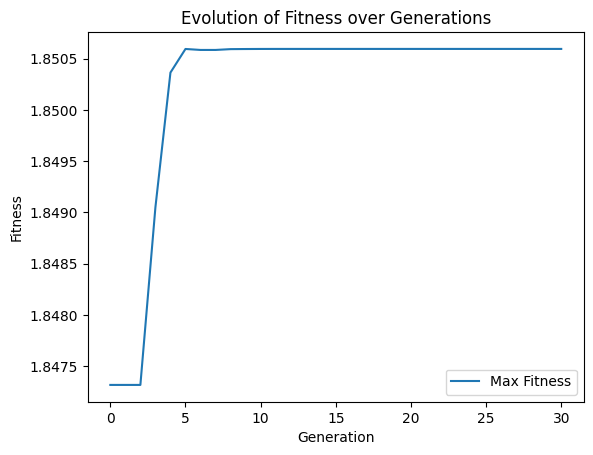

In [6]:
gen = log.select("gen")
max_fitness = log.select("max")
plt.plot(gen, max_fitness, label="Max Fitness")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.title("Evolution of Fitness over Generations")
plt.legend()
plt.show()

## 6. Conclusion
This notebook provided a simple, explainable implementation of a distributed evolutionary algorithm using DEAP. You can extend this by using multiprocessing or distributed computing features in DEAP for larger problems.